# PK/PD Antibiotic Model: Example Workflow

This notebook demonstrates how to use the PK/PD modeling framework to:

- run a baseline simulation

- visualize antibiotic concentration and bacterial burden over time

- perform a parameter sweep

- compare treatment outcomes across conditions

The core model code is imported from `src/pkpd_model.py`.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Add the parent directory to the Python path so we can import from src/

# This is necessary because the notebook is inside the "notebooks" folder

sys.path.append(os.path.abspath(".."))

# Import core model functions

from src.pkpd_model import *

In [2]:
## INITIALIZE MODEL PARAMETERS ##

# Create default model parameters (PK, PD, and biological parameters)
params = create_params()

# Create default simulation settings (dose, interval, simulation time, etc.)
sim_settings = create_sim_settings()

# Display the parameter dictionaries
params, sim_settings

({'half_life': 6.0,
  'V': 1,
  'r': 0.8,
  'Bmax': 1000000000.0,
  'Emax': 1.0,
  'EC50': 0.5},
 {'dose_mg': 10,
  'dose_interval': 12,
  'n_doses': 10,
  't_end': 120,
  'B0': 1000000.0})

In [3]:
## Run a single PK/PD simulation using default parameters ##

# Outputs:
# t = time points
# C = drug concentration over time
# B = bacterial burden over time
t, C, B = run_simulation(params = params, sim_settings = sim_settings)

# Print final bacterial burden for quick reference
print(f"Final bacterial burden: {B[-1]:.2e}")

Final bacterial burden: 4.08e-01


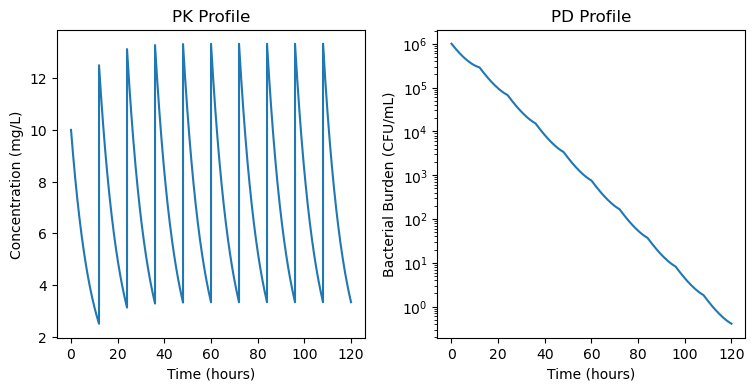

In [25]:
## PLOT PK/PD PROFILES ##

# Create a figure with two subplots: PK (left) and PD (right)
fig, axes = plt.subplots(1, 2, figsize = (9, 4))

# Plot PK: drug concentration over time
axes[0].plot(t, C)
axes[0].set_title("PK Profile")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Concentration (mg/L)")
axes[0].set_box_aspect(1)

# Plot PD: bacterial burden over time (log scale for clarity)
axes[1].plot(t, B)
axes[1].set_yscale("log")
axes[1].set_title("PD Profile")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Bacterial Burden (CFU/mL)")
axes[1].set_box_aspect(1)

plt.show()

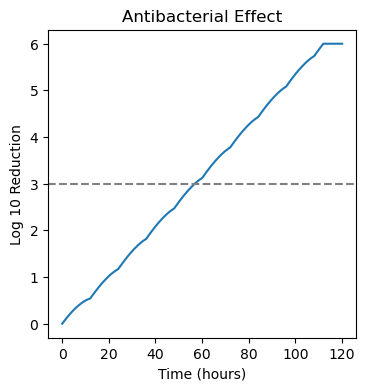

In [23]:
## COMPUTE AND PLOT LOG REDUCTION ##

# Set a detection limit to avoid log(0) issues
DETECTION_LIMIT = 1.0

# Ensure bacterial burden never goes below detection limit
B_safe = np.maximum(B, DETECTION_LIMIT)

# Initial bacterial burden
B0 = B_safe[0]

# Compute log10 reduction over time

# This represents how many orders of magnitude the bacteria have been reduced
log_reduction = np.log10(B0 / B_safe)

# Plot antibacterial effect
plt.figure(figsize = (4, 4))
plt.plot(t, log_reduction)
ax = plt.gca()  # get current axis
ax.set_box_aspect(1)

# Add reference line for 3-log reduction (bactericidal threshold)
plt.axhline(3, linestyle="--", color="gray")
plt.xlabel("Time (hours)")
plt.ylabel("Log 10 Reduction")
plt.title("Antibacterial Effect")
plt.show()

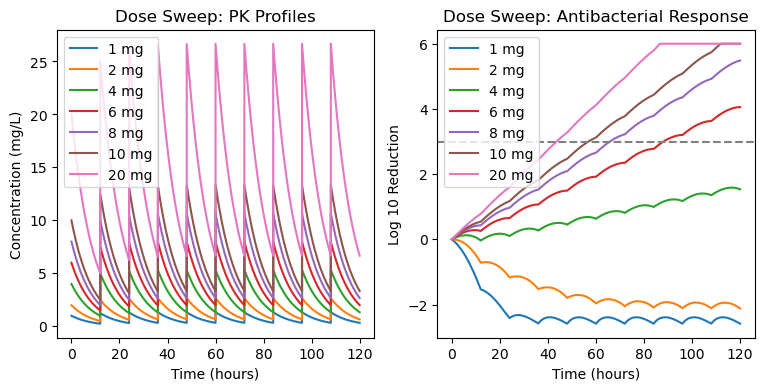

In [33]:
## EXAMPLE DOSE SWEEP (PK) ##

# Run simulations across a range of doses
# All other parameters are held constant

dose_results = run_sim_setting_sweep(
    setting_name="dose_mg",
    values=np.array([1, 2, 4, 6, 8, 10, 20]),
    params=params,
    base_sim_settings=sim_settings,
)

# Create a figure with two subplots: PK (left) and PD (right)
fig, axes = plt.subplots(1, 2, figsize = (9, 4))

# Plot concentration-time profiles for each dose
for dose, out in dose_results.items():
    axes[0].plot(out["t"], out["C"], label=f"{dose} mg")

axes[0].set_title("Dose Sweep: Antibacterial Concentration")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Concentration (mg/L)")
axes[0].set_title("Dose Sweep: PK Profiles")
axes[0].legend()

# Plot log-reduction profiles for each dose
for dose, out in dose_results.items():
    B_safe = np.maximum(out["B"], DETECTION_LIMIT)
    B0 = B_safe[0]
    log_reduction = np.log10(B0 / B_safe)
    axes[1].plot(out["t"], log_reduction, label=f"{dose} mg")

# Add 3-log reference line

axes[1].axhline(3, linestyle="--", color="gray")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Log 10 Reduction")
axes[1].set_title("Dose Sweep: Antibacterial Response")
axes[1].legend()

plt.show()

In [34]:
# Store summary metrics for each dose

summary = []

for dose, out in dose_results.items():
    B_safe = np.maximum(out["B"], DETECTION_LIMIT)
    B0 = B_safe[0]
    log_reduction = np.log10(B0 / B_safe)

    # Final log reduction at end of simulation
    final_log = log_reduction[-1]

    summary.append({
        "dose": dose,
        "AUC": out["AUC"],  # total drug exposure
        "final_log_reduction": final_log
    })

# Convert to DataFrame for easy viewing
summary_df = pd.DataFrame(summary).sort_values("dose")
summary_df

,dose,AUC,final_log_reduction
0,1,83.677438,-2.586390
1,2,167.355735,-2.120211
2,4,334.714937,1.533267
3,6,502.077304,4.055365
4,8,669.430610,5.485067
5,10,836.784936,6.000000
6,20,1673.561553,6.000000


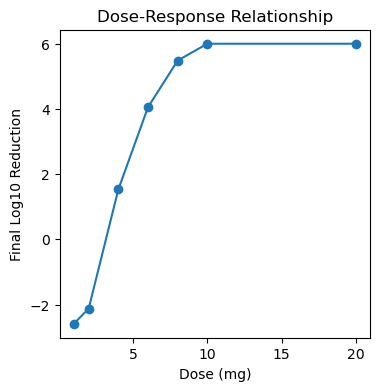

In [36]:
# Plot final antibacterial effect as a function of dose

plt.figure(figsize = (4, 4))
plt.plot(summary_df["dose"], summary_df["final_log_reduction"], marker="o")
plt.xlabel("Dose (mg)")
plt.ylabel("Final Log10 Reduction")
plt.title("Dose-Response Relationship")
plt.show()